##  Indian Sign Language Recognition using CNN

###  Objective
To build a deep learning model that recognizes Indian Sign Language gestures from images.

###  Goals
- Load dataset correctly
- Preprocess images
- Train CNN model
- Evaluate performance

###  Use Case
Helps deaf and mute individuals communicate effectively.

### IMPORT LIBRARIES

In [2]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
#DOWNLOAD + EXTRACT DATASET
import requests, zipfile, io

url = "https://d3ilbtxij3aepc.cloudfront.net/projects/AI-Capstone-Projects/PRAICP-1000-IndiSignLang.zip"

print("Downloading dataset...")
r = requests.get(url)

z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("dataset")

print("✅ Dataset ready")

✅ Dataset ready


In [4]:
print(os.listdir("dataset"))

['Data', 'Meta', 'Meta.csv', 'Test', 'Test.csv', 'Train', 'Train.csv']


In [5]:
dataset_path = "dataset"

# Auto-fix (important)
if "Train" in os.listdir(dataset_path):
    dataset_path = os.path.join(dataset_path, "Train")

print("Using dataset path:", dataset_path)

Using dataset path: dataset\Train


###  Data Preprocessing

- Resize images to 64x64
- Normalize pixel values
- Convert labels to numeric format
- Handle invalid files safely

In [6]:
#LOAD IMAGES
data = []
labels = []

img_size = 64

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    # skip non-folders
    if not os.path.isdir(folder_path):
        continue

    for img in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img)

        try:
            image = cv2.imread(img_path)

            if image is None:
                continue

            image = cv2.resize(image, (img_size, img_size))

            data.append(image)
            labels.append(folder)

        except:
            pass

data = np.array(data) / 255.0
labels = np.array(labels)

print("✅ Data shape:", data.shape)
print("✅ Classes:", np.unique(labels))

✅ Data shape: (39209, 64, 64, 3)
✅ Classes: ['0' '1' '10' '11' '12' '13' '14' '15' '16' '17' '18' '19' '2' '20' '21'
 '22' '23' '24' '25' '26' '27' '28' '29' '3' '30' '31' '32' '33' '34' '35'
 '36' '37' '38' '39' '4' '40' '41' '42' '5' '6' '7' '8' '9']


In [7]:
from collections import Counter
print("Class Distribution:", Counter(labels))

Class Distribution: Counter({np.str_('2'): 2250, np.str_('1'): 2220, np.str_('13'): 2160, np.str_('12'): 2100, np.str_('38'): 2070, np.str_('10'): 2010, np.str_('4'): 1980, np.str_('5'): 1860, np.str_('25'): 1500, np.str_('9'): 1470, np.str_('7'): 1440, np.str_('3'): 1410, np.str_('8'): 1410, np.str_('11'): 1320, np.str_('18'): 1200, np.str_('35'): 1200, np.str_('17'): 1110, np.str_('14'): 780, np.str_('31'): 780, np.str_('33'): 689, np.str_('15'): 630, np.str_('26'): 600, np.str_('28'): 540, np.str_('23'): 510, np.str_('30'): 450, np.str_('16'): 420, np.str_('34'): 420, np.str_('6'): 420, np.str_('22'): 390, np.str_('36'): 390, np.str_('20'): 360, np.str_('40'): 360, np.str_('21'): 330, np.str_('39'): 300, np.str_('24'): 270, np.str_('29'): 270, np.str_('27'): 240, np.str_('32'): 240, np.str_('41'): 240, np.str_('42'): 240, np.str_('0'): 210, np.str_('19'): 210, np.str_('37'): 210})


In [8]:
print("Folders inside Train:", os.listdir(dataset_path)[:10])

Folders inside Train: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17']


In [9]:
print("Number of classes:", len(np.unique(labels)))

Number of classes: 43


### LABEL ENCODING

In [10]:
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

y = to_categorical(labels_encoded)

In [11]:
y

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]])

### TRAIN TEST SPLIT

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    data, y, test_size=0.2, random_state=42, stratify=labels_encoded
)

### DATA AUGMENTATION

In [14]:
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train)

### BUILD CNN MODEL

In [15]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(len(np.unique(labels)), activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

C:\Users\admin\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       1,605,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 43)                  │           5,547 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,630,699 (6.22 MB)

 Trainable params: 1,630,699 (6.22 MB)

 Non-trainable params: 0 (0.00 B)

### TRAIN MODEL

In [16]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=15,
    validation_data=(X_test, y_test)
)

C:\Users\admin\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 152s 151ms/step - accuracy: 0.6278 - loss: 1.2739 - val_accuracy: 0.8815 - val_loss: 0.4277
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 131s 133ms/step - accuracy: 0.8684 - loss: 0.4372 - val_accuracy: 0.9374 - val_loss: 0.2278
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 137s 139ms/step - accuracy: 0.9132 - loss: 0.2919 - val_accuracy: 0.9478 - val_loss: 0.1607
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 132s 135ms/step - accuracy: 0.9308 - loss: 0.2338 - val_accuracy: 0.9593 - val_loss: 0.1421
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 123s 125ms/step - accuracy: 0.9427 - loss: 0.1852 - val_accuracy: 0.9667 - val_loss: 0.1143
Epoch 6/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 128s 131ms/step - accuracy: 0.9509 - loss: 0.1614 - val_accuracy: 0.9689 - val_loss: 0.1063
Epoch 7/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 122s 124ms/step - accuracy: 0.9564 - loss: 0.1427 - val_accuracy: 0.9725 - val_loss: 0.0961
Epoch 8/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 120s 123ms/step - accuracy: 0.9622 -

### EVALUATION

In [17]:
pred = model.predict(X_test)

pred_classes = np.argmax(pred, axis=1)
true_classes = np.argmax(y_test, axis=1)

print("Accuracy:", accuracy_score(true_classes, pred_classes))
print(classification_report(true_classes, pred_classes))

246/246 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step
Accuracy: 0.9831675592960979
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        42
           1       1.00      0.96      0.98       444
           2       1.00      1.00      1.00       402
           3       1.00      0.98      0.99       264
           4       1.00      1.00      1.00       420
           5       1.00      0.99      0.99       432
           6       1.00      1.00      1.00       156
           7       0.99      1.00      1.00       126
           8       0.98      1.00      0.99        84
           9       1.00      1.00      1.00       222
          10       1.00      1.00      1.00       240
          11       0.86      1.00      0.92        42
          12       0.98      0.98      0.98       450
          13       0.97      0.90      0.94        72
          14       1.00      0.97      0.98        66
          15       1.00      1.00      1.00        78
          

### CONFUSION MATRIX

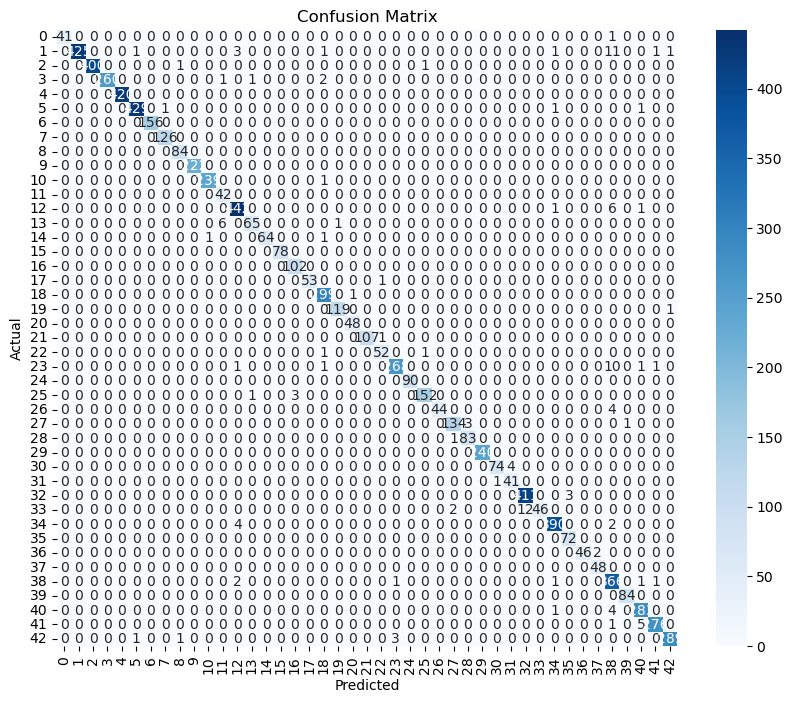

In [18]:
import seaborn as sns

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### ACCURACY GRAPH

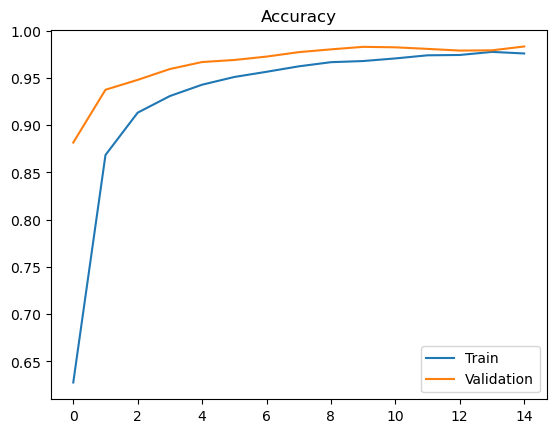

In [19]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Accuracy")
plt.show()

### SAVE MODEL

In [20]:
model.save("isl_model.h5")
print("✅ Model saved")

✅ Model saved


###  Model Performance Analysis

The model achieved an overall accuracy of **98.3%**, indicating strong performance in recognizing Indian Sign Language gestures.

###  Key Observations:
- Most classes achieved precision and recall above 95%
- A few classes showed slightly lower performance due to visual similarity between gestures

### Conclusion

- Successfully developed ISL recognition system using CNN
- Applied data augmentation to improve generalization
- Evaluated model using confusion matrix

###  Future Scope
- Real-time gesture detection using webcam
- Mobile deployment
- Transfer learning (ResNet, MobileNet)